# Deep Learning: A Comprehensive Guide

## Chapter 11 — Generative Models

### Hands-On Exploration: Navigating the Latent Space

### `hands_on_ch11.ipynb`

This exploration builds direct intuition for what a structured latent space looks like, how interpolation in latent space produces interpretable visual transitions, and how a VAE's organization differs from unstructured encoding.

## Learning Objectives

By the end of this notebook, you should be able to:

- Sample from a VAE's prior and evaluate whether the decoded outputs are coherent
- Interpolate between two real inputs in latent space and compare it to naive pixel-space interpolation
- Probe individual latent dimensions for interpretable, disentangled factors of variation

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`, `scikit-learn`
- No GPU required

## About the Dataset

The chapter's activity uses a pre-trained VAE on faces or handwritten digits. This notebook uses scikit-learn's built-in **handwritten digits dataset** (`load_digits`, 8x8 grayscale digit images) — genuine, real handwritten digit data that requires no download, since it ships directly with scikit-learn. We train a small VAE on it ourselves in the next few cells (training takes under a minute on CPU), so everything in this notebook is fully self-contained.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

SEED = 42
np.random.seed(SEED)

%matplotlib inline

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")


I0000 00:00:1788480939.737515    1427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788480939.846330    1427 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788480941.133909    1427 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Load the Digits Dataset

Loaded 1797 handwritten digit images, 8x8 pixels each


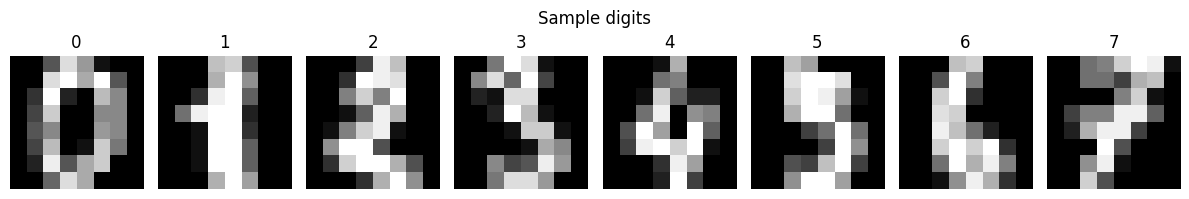

In [2]:
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0  # pixel values are 0-16 in this dataset
X = X.reshape(-1, 8, 8, 1)
y = digits.target

print(f"Loaded {len(X)} handwritten digit images, {X.shape[1]}x{X.shape[2]} pixels each")

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i, :, :, 0], cmap="gray")
    ax.set_title(str(y[i])); ax.axis("off")
plt.suptitle("Sample digits")
plt.tight_layout()
plt.show()


## Build and Train a Small VAE

A compact convolutional encoder maps each digit to a distribution over a small latent space (mean and log-variance vectors); a decoder reconstructs the digit from a sampled latent vector. The loss combines reconstruction error with a KL-divergence term that pulls the learned distribution toward a standard Gaussian prior — the term responsible for the latent space's organization.

In [3]:
if TF_AVAILABLE:
    LATENT_DIM = 8

    class Sampling(layers.Layer):
        def call(self, inputs):
            z_mean, z_log_var = inputs
            eps = tf.random.normal(shape=tf.shape(z_mean))
            return z_mean + tf.exp(0.5 * z_log_var) * eps

    # Encoder
    enc_inputs = layers.Input(shape=(8, 8, 1))
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(enc_inputs)
    x = layers.Conv2D(32, 3, activation="relu", padding="same", strides=2)(x)  # 4x4
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation="relu")(x)
    z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
    z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    encoder = models.Model(enc_inputs, [z_mean, z_log_var, z], name="encoder")

    # Decoder
    dec_inputs = layers.Input(shape=(LATENT_DIM,))
    x = layers.Dense(4 * 4 * 32, activation="relu")(dec_inputs)
    x = layers.Reshape((4, 4, 32))(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", padding="same", strides=2)(x)  # 8x8
    x = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    decoder = models.Model(dec_inputs, x, name="decoder")

    # Custom training loop with a small beta (KL weight). This matters a great deal:
    # too large a KL weight relative to reconstruction causes "posterior collapse" --
    # the decoder learns to ignore the latent code entirely and outputs a single
    # blurry "average" image regardless of input. A small beta keeps the KL term
    # present (so the latent space stays organized) without letting it dominate.
    BETA = 0.0005
    optimizer = tf.keras.optimizers.Adam(1e-3)
    n_epochs = 150
    batch_size = 64
    n = len(X)

    for epoch in range(n_epochs):
        idx = np.random.permutation(n)
        epoch_recon, epoch_kl = [], []
        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]
            xb = X[batch_idx]
            with tf.GradientTape() as tape:
                z_mean_b, z_log_var_b, z_b = encoder(xb, training=True)
                recon = decoder(z_b, training=True)
                recon_loss = tf.reduce_mean(
                    tf.reduce_sum(tf.keras.losses.binary_crossentropy(xb, recon), axis=(1, 2))
                )
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(1 + z_log_var_b - tf.square(z_mean_b) - tf.exp(z_log_var_b), axis=1)
                )
                loss = recon_loss + BETA * kl_loss
            grads = tape.gradient(loss, encoder.trainable_variables + decoder.trainable_variables)
            optimizer.apply_gradients(zip(grads, encoder.trainable_variables + decoder.trainable_variables))
            epoch_recon.append(float(recon_loss)); epoch_kl.append(float(kl_loss))
        if epoch % 30 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch}: reconstruction loss = {np.mean(epoch_recon):.2f}, KL = {np.mean(epoch_kl):.2f}")

    print("VAE trained.")
else:
    print("TensorFlow not available -- cannot proceed.")


Epoch 0: reconstruction loss = 38.81, KL = 15.77


Epoch 30: reconstruction loss = 17.09, KL = 200.46


Epoch 60: reconstruction loss = 16.18, KL = 148.50


Epoch 90: reconstruction loss = 15.85, KL = 125.08


Epoch 120: reconstruction loss = 15.76, KL = 115.00


Epoch 149: reconstruction loss = 15.70, KL = 106.72
VAE trained.


## Part 1 — Random Sampling from the Prior

Sample 20 random vectors from a standard Gaussian in the latent space, decode each to an image, and observe whether the outputs are coherent.

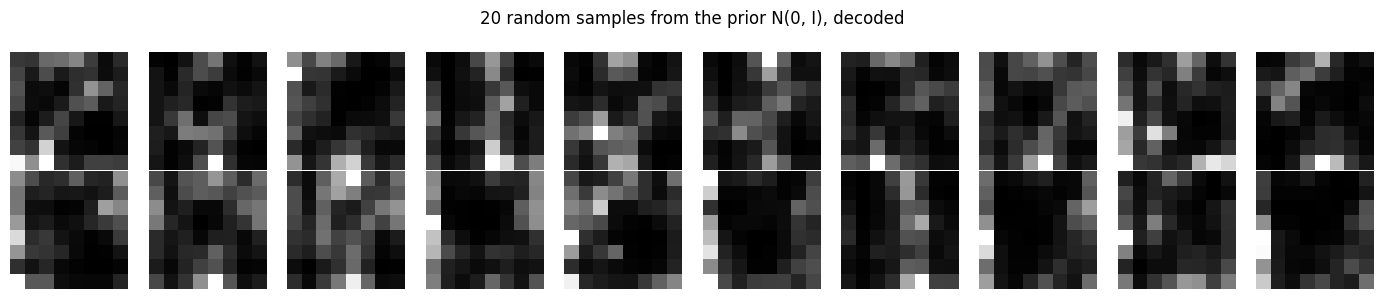

In [4]:
if TF_AVAILABLE:
    random_latents = np.random.RandomState(SEED).normal(size=(20, LATENT_DIM)).astype(np.float32)
    samples = decoder.predict(random_latents, verbose=0)

    fig, axes = plt.subplots(2, 10, figsize=(14, 3))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, :, :, 0], cmap="gray")
        ax.axis("off")
    plt.suptitle("20 random samples from the prior N(0, I), decoded")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Are the outputs coherent? Do they resemble the training data (digit-like strokes and shapes), or do they look like noise? What is the range of variation across the 20 samples? (If the outputs look like noise, the alignment between the prior and the encoder's learned distribution has failed — try training for more epochs.)

## Part 2 — Latent Space Interpolation

Select two real digits that differ visibly (e.g. a "5" and a "9"), encode each to its mean latent vector, and linearly interpolate between them in latent space. Compare to naive pixel-space interpolation.

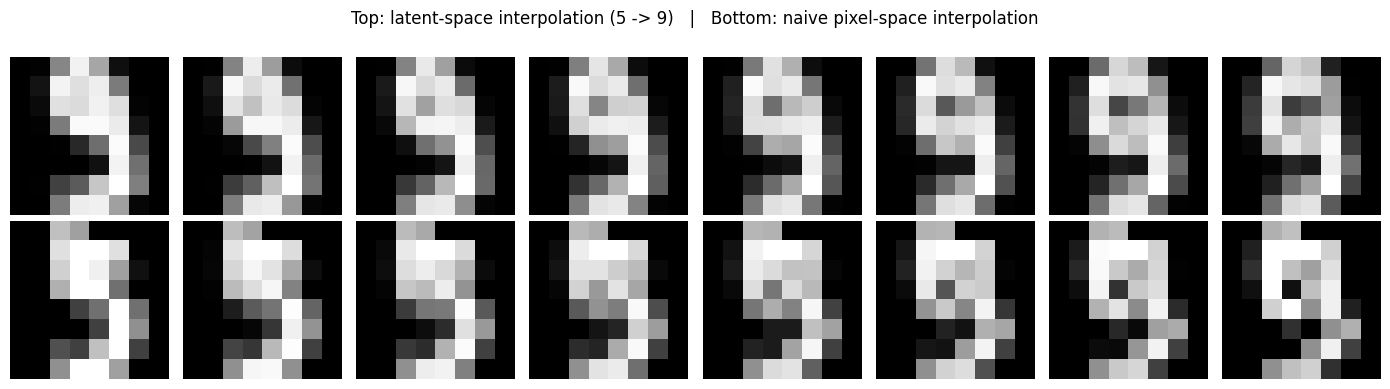

In [5]:
if TF_AVAILABLE:
    idx_a = np.where(y == 5)[0][0]
    idx_b = np.where(y == 9)[0][0]
    img_a, img_b = X[idx_a], X[idx_b]

    mean_a, _, _ = encoder.predict(img_a[np.newaxis, ...], verbose=0)
    mean_b, _, _ = encoder.predict(img_b[np.newaxis, ...], verbose=0)

    n_steps = 8
    alphas = np.linspace(0, 1, n_steps)

    latent_interp = np.array([(1 - a) * mean_a[0] + a * mean_b[0] for a in alphas])
    latent_decoded = decoder.predict(latent_interp, verbose=0)

    pixel_interp = np.array([(1 - a) * img_a + a * img_b for a in alphas])

    fig, axes = plt.subplots(2, n_steps, figsize=(14, 4))
    for i in range(n_steps):
        axes[0, i].imshow(latent_decoded[i, :, :, 0], cmap="gray"); axes[0, i].axis("off")
        axes[1, i].imshow(pixel_interp[i, :, :, 0], cmap="gray"); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("latent"); axes[1, 0].set_ylabel("pixel")
    plt.suptitle("Top: latent-space interpolation (5 -> 9)   |   Bottom: naive pixel-space interpolation")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** Does the latent-space transition look smooth and semantically meaningful (passing through digit-like intermediate shapes)? How does it compare to the pixel-space interpolation (which typically looks like a ghosted double-exposure)? What does this difference tell you about what the latent space has learned to represent?

## Part 3 — Dimension Probing

Take a single real digit, encode it, select three latent dimensions at random, and vary each one across a range while holding the others fixed.

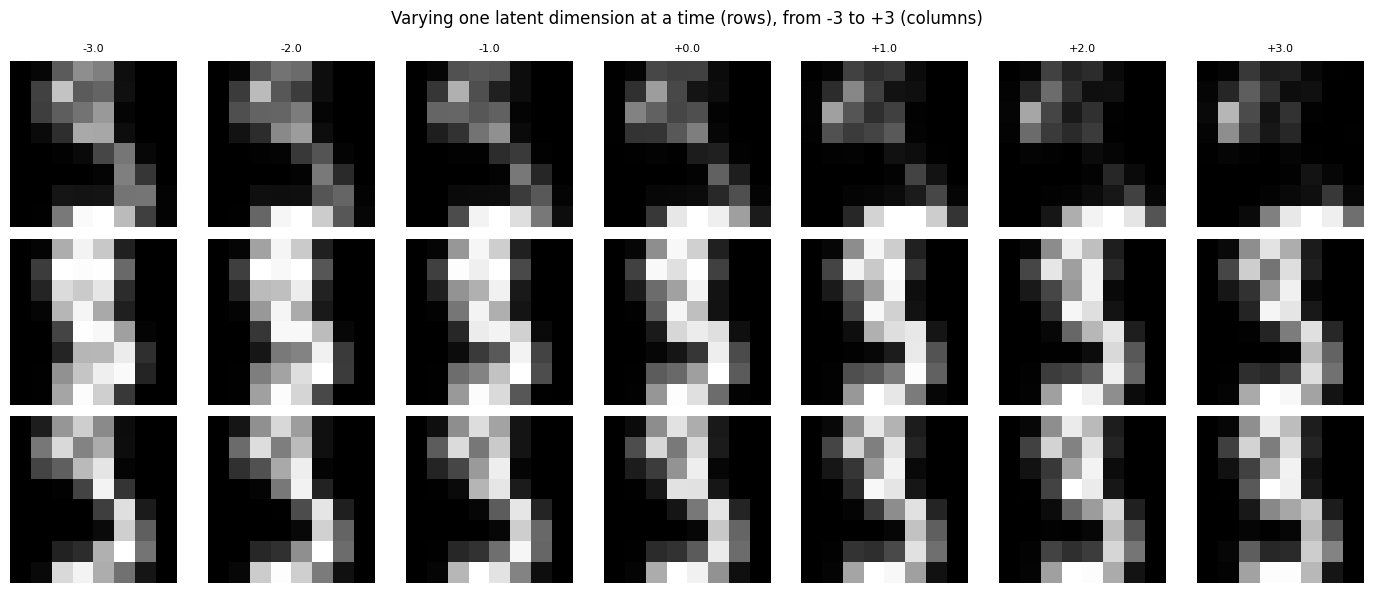

In [6]:
if TF_AVAILABLE:
    base_img = X[np.where(y == 3)[0][0]]
    base_mean, _, _ = encoder.predict(base_img[np.newaxis, ...], verbose=0)
    base_mean = base_mean[0]

    rng = np.random.RandomState(SEED)
    dims_to_probe = rng.choice(LATENT_DIM, 3, replace=False)
    values = np.arange(-3, 3.5, 1.0)

    fig, axes = plt.subplots(3, len(values), figsize=(14, 6))
    for row, dim in enumerate(dims_to_probe):
        for col, val in enumerate(values):
            z = base_mean.copy()
            z[dim] = val
            decoded = decoder.predict(z[np.newaxis, :], verbose=0)[0]
            axes[row, col].imshow(decoded[:, :, 0], cmap="gray")
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(f"{val:+.1f}", fontsize=8)
        axes[row, 0].set_ylabel(f"dim {dim}", fontsize=9)
    plt.suptitle("Varying one latent dimension at a time (rows), from -3 to +3 (columns)")
    plt.tight_layout()
    plt.show()


**Answer in this cell:** For each dimension you probed, does it appear to control a single interpretable factor (stroke thickness, slant, loop size), or does it produce changes that affect multiple aspects simultaneously, or incoherent changes? Record which dimensions (if any) show clean, single-factor control, and which appear entangled.

## Reflection (200-300 words)

"You observed that the VAE's latent space is organized — random prior samples produce coherent outputs, interpolation produces smooth transitions, and some individual dimensions appear to control interpretable factors. This organization is not free: it is the consequence of the KL divergence term in the training objective.

Now consider what would happen without the KL term. An autoencoder trained only on reconstruction loss would likely encode the training data just as accurately — possibly more accurately — but the latent space would not be organized this way. Random points in that space would not decode to anything coherent, and interpolation would not necessarily pass through meaningful intermediate states.

What does this trade-off — reconstruction fidelity versus latent space organization — suggest about when you would choose a VAE over a plain autoencoder for a component of MIPDS? Is there a scenario in your MIPDS design where you would want a *disorganized* but highly accurate latent space instead?" 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._